In [20]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections

In [2]:
data = pd.read_csv("final_defesas_2006a2024.csv")

In [76]:
data["orientador"].value_counts()

orientador
Selenium_error                   75
sem orcid                        59
orcid.org/0000-0001-9772-263X    52
orcid.org/0000-0003-0125-630X    50
orcid.org/0000-0002-4830-5298    43
                                 ..
orcid.org/0000-0003-0750-0502     1
orcid.org/0000-0002-0323-9207     1
orcid.org/0000-0001-5968-7108     1
orcid.org/0000-0001-7810-0595     1
orcid.org/0000-0003-0499-2564     1
Name: count, Length: 65, dtype: int64

In [79]:
# descobrindo onde tem mais "selenium error"

data[data["orientador"]=="Selenium_error"]["ano"].value_counts()

ano
2021    57
2023    17
2022     1
Name: count, dtype: int64

In [3]:
data["orientador_nome"].value_counts()

orientador_nome
sem orcid                             59
Ricardo Torres                        52
Helio Pedrini                         50
Maria Cecilia Calani Baranauskas      43
Nelson L. S. da Fonseca               39
                                      ..
Alexandru Cristian Telea               1
Antonio Carlos Rodrigues de Amorim     1
Torsten Braun                          1
BULGARELI, J V                         1
Marcos M. Raimundo                     1
Name: count, Length: 64, dtype: int64

In [4]:
data["orientador_genero"].value_counts()

orientador_genero
Masculino    715
Feminino     179
Name: count, dtype: int64

## Criação dos grafos e dos nós

In [35]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas = nx.DiGraph()
n_banca = 0
for col in data.columns[2:]:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in enumerate(data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        grafo_defesas.add_node(url.split("/")[-1],
                            #    papel=col,
                               nome=data.at[index, f"{col}_nome"],
                               filiacao=data.at[index, f"{col}_filiação"],
                               orcid=url.split("/")[-1],
                               genero=data.at[index, f"{col}_genero"])
    n_banca -=- 1

In [36]:
for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas.has_edge(orcid_orient, orcid_aval):
            grafo_defesas[orcid_orient][orcid_aval]["qtd"] -=- 1
            continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, qtd=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
for p1, p2 in grafo_defesas.edges:
    edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [37]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas.out_degree() if degree == max_degree_out]

In [38]:
maior_n_contribs = 0
for node in grafo_defesas:
   for colab in grafo_defesas[node]:
      if grafo_defesas[node][colab]["qtd"] > maior_n_contribs:
         maior_n_contribs = grafo_defesas[node][colab]["qtd"]

maiores_contribs = []
for node in grafo_defesas:
   for colab in grafo_defesas[node]:
      if grafo_defesas[node][colab]["qtd"] == maior_n_contribs:
         maiores_contribs.append((grafo_defesas.nodes[node]['nome'], grafo_defesas.nodes[colab]['nome']))

In [39]:
edge_colors = []
for p1, p2 in grafo_defesas.edges:
    if (grafo_defesas.nodes[p1]['nome'], grafo_defesas.nodes[p2]['nome']) in maiores_contribs:
        edge_colors.append("red")
    else:
        edge_colors.append("k")

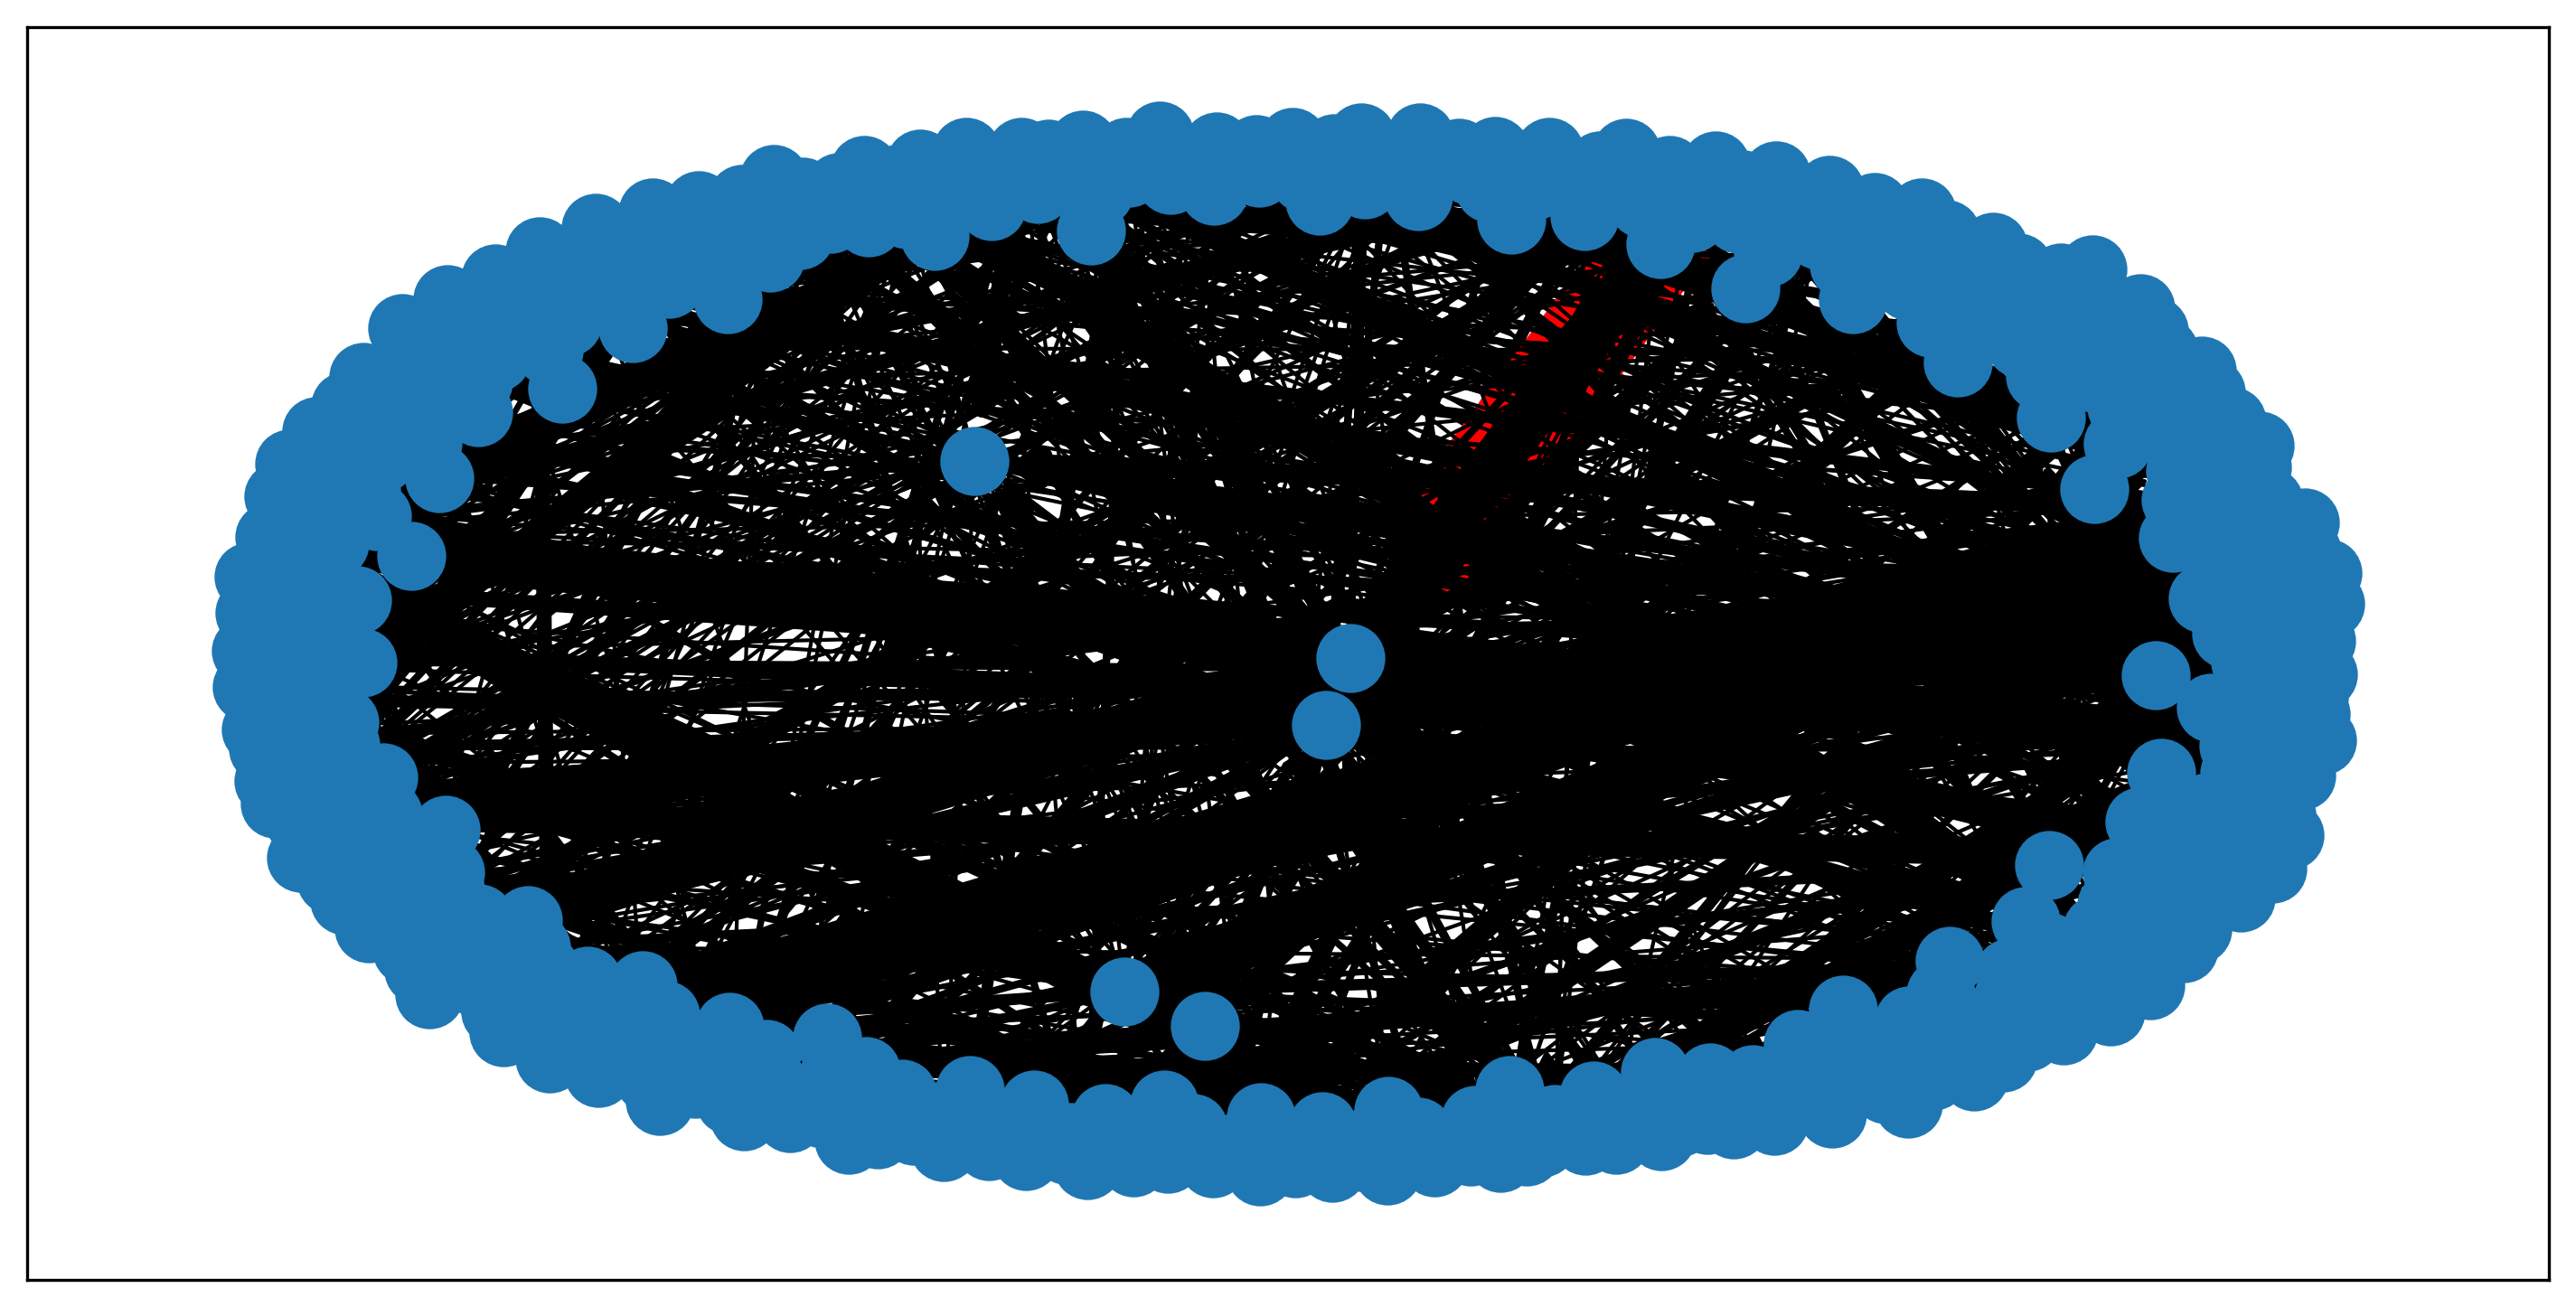

In [28]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6), dpi=300)
pos = nx.spring_layout(grafo_defesas, k=2, seed = 1931)

# nx.draw(grafo_defesas, with_labels=False, font_weight='bold', pos=pos)
nx.draw_networkx_nodes(grafo_defesas, pos=pos)
nx.draw_networkx_edges(grafo_defesas, pos=pos, width=edge_widths, edge_color=edge_colors)
plt.show()

In [57]:
grafo_defesas.nodes['0000-0002-6540-8686']

{'nome': 'Paulo de Geus',
 'filiacao': 'University of Campinas',
 'orcid': '0000-0002-6540-8686',
 'genero': 'Masculino'}

In [44]:
grafo_defesas.in_degree()

InDegreeView({'0000-0002-6540-8686': 3, '0000-0003-4869-5190': 7, '0000-0001-5685-8004': 9, '0000-0002-2914-5380': 5, '0000-0001-5201-1244': 8, '0000-0003-2046-602X': 3, '0000-0002-8856-194X': 9, '0000-0002-1067-6421': 7, '0000-0002-1180-2637': 14, '0000-0002-4830-5298': 7, '0000-0003-4549-7105': 3, '0000-0003-4290-6508': 4, '0000-0003-3333-6822': 3, '0000-0003-1908-4753': 8, '0000-0002-6023-5982': 14, '0000-0002-5945-0845': 6, '0000-0002-7002-875X': 9, '0000-0002-1914-5790': 1, '0000-0002-3891-1593': 3, '0000-0002-3823-8941': 8, '0000-0002-8803-0401': 10, '0000-0001-7878-4990': 5, '0000-0001-9772-263X': 15, '0000-0002-3159-4839': 4, '0000-0002-6731-1482': 5, '0000-0002-9539-6874': 9, '0000-0001-8923-0432': 1, '0000-0003-4462-3325': 8, '0000-0001-5015-2131': 5, '0000-0001-8309-6367': 9, '0000-0001-9174-2816': 2, '0000-0003-0683-7672': 4, '0000-0001-6030-2682': 10, '0000-0002-9529-4253': 3, '0000-0003-0125-630X': 19, '0000-0002-1756-4852': 11, '0000-0002-4236-8212': 5, '0000-0003-4237-4

In [55]:
node_shape = []
for v in grafo_defesas.nodes:
    # genero = data
    node_shape.append("<" if grafo_defesas.nodes[v]["genero"] == "Masculine" else ">")
    # print(v)
    # print(grafo_defesas.nodes[v]["genero"])
    # break

### Gráfico log-log com graus de saída (orientação->avaliação)

In [60]:
degree_sequence = [d for _, d in grafo_defesas.out_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

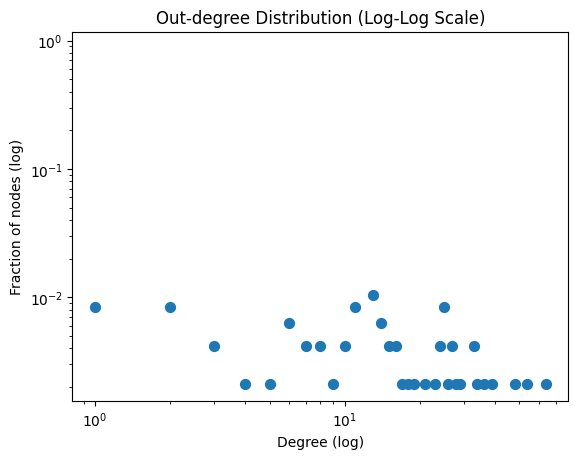

In [62]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Out-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

### Gráfico log-log com graus de entrada (avaliação<-orientação)

In [63]:
degree_sequence = [d for _, d in grafo_defesas.in_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

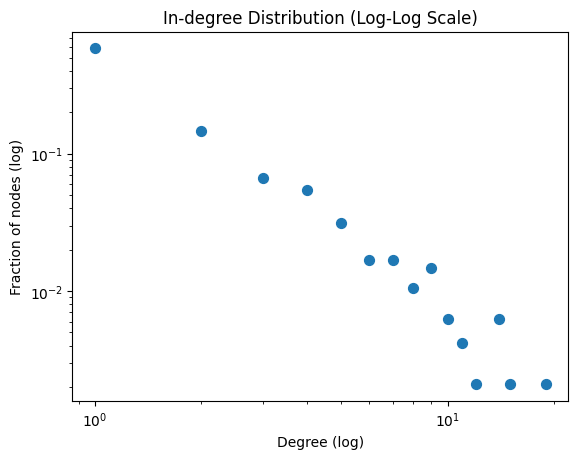

In [65]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("In-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

### Gráfico log-log com graus de entrada e saída

In [66]:
degree_sequence = [d for _, d in grafo_defesas.degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

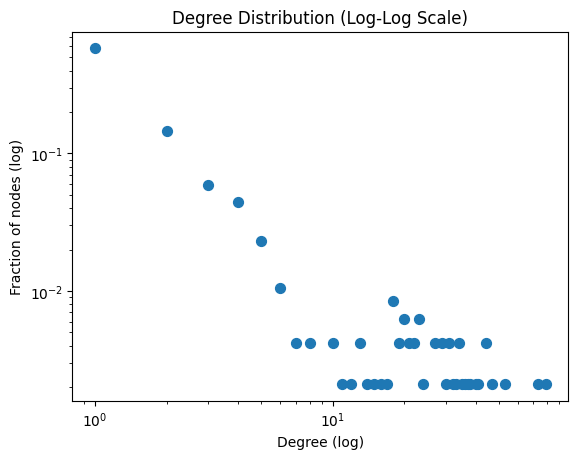

In [70]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt/len(grafo_defesas), s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()